## Import Library

In [1]:
import os
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import lightgbm as lgb
import xgboost as xgb
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import sklearn

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"tensorflow : {tf.__version__}")
print(f"lightgbm : {lgb.__version__}")
print(f"xgboost : {xgb.__version__}")
print(f"optuna : {optuna.__version__}")
print(f"GPU tersedia : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"random seed : {SEED}")

python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
scikit-learn : 1.6.1
tensorflow : 2.20.0
lightgbm : 4.6.0
xgboost : 3.2.0
optuna : 4.9.0
GPU tersedia : True
random seed : 42


## Load Data & Split Train

In [2]:
from sklearn.model_selection import train_test_split

FEATURES_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02/features_gold.csv"
SPLIT_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02/split_assignment.csv"

features = pd.read_csv(FEATURES_PATH)
split = pd.read_csv(SPLIT_PATH)

train_rows = split[split.split == "train"].copy()
fit_rows, calib_rows = train_test_split(
    train_rows, test_size=0.20, stratify=train_rows["class"], random_state=SEED
)
fit_paths = fit_rows["path"]
calib_paths = calib_rows["path"]
val_paths = split.loc[split.split == "val", "path"]

print(f"train_fit   : {len(fit_paths)} eksekusi (melatih model)")
print(f"train_calib : {len(calib_paths)} eksekusi (membangun tabel Economy-gamma-lite)")
print(f"val         : {len(val_paths)} eksekusi (objektif Optuna)")

train_fit   : 805 eksekusi (melatih model)
train_calib : 202 eksekusi (membangun tabel Economy-gamma-lite)
val         : 216 eksekusi (objektif Optuna)


## Sequence & Pre Processing

In [3]:
STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]

LOG1P_FEATURES = (
    ["T_s_r", "T_s_w", "V_s_r", "V_s_w"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
LOG1P_IDX = [FEATURE_COLUMNS_FULL.index(f) for f in LOG1P_FEATURES]

STEP_CHOICES = [5, 10]
N_TRIALS_PER_MODEL = 100


def checkpoints_for_step(step, max_w=30):
    return list(range(step, max_w + 1, step))


def build_sequences(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels = [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid)
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y


def apply_log1p(X, idx):
    X = X.copy()
    X[..., idx] = np.log1p(np.clip(X[..., idx], a_min=0.0, a_max=None))
    return X


def scale_3d(X, scaler):
    shp = X.shape
    return scaler.transform(X.reshape(-1, shp[-1])).reshape(shp).astype("float32")


def prepare_split_data(step):
    grid = checkpoints_for_step(step)
    X_fit_raw, y_fit = build_sequences(features, fit_paths, grid, ALL_FEATURE_NAMES)
    X_calib_raw, y_calib = build_sequences(features, calib_paths, grid, ALL_FEATURE_NAMES)
    X_val_raw, y_val = build_sequences(features, val_paths, grid, ALL_FEATURE_NAMES)

    X_fit_log = apply_log1p(X_fit_raw, LOG1P_IDX)
    X_calib_log = apply_log1p(X_calib_raw, LOG1P_IDX)
    X_val_log = apply_log1p(X_val_raw, LOG1P_IDX)
    scaler = StandardScaler().fit(X_fit_log.reshape(-1, X_fit_log.shape[-1]))

    X_fit = scale_3d(X_fit_log, scaler)
    X_calib = scale_3d(X_calib_log, scaler)
    X_val = scale_3d(X_val_log, scaler)
    return grid, X_fit, y_fit, X_calib, y_calib, X_val, y_val

## Mekanisme Economy-γ-lite

In [4]:
def cost_sensitive_predict(p, beta):
    threshold = 1.0 / (1.0 + beta)
    return (p > threshold).astype(int)


def build_economy_table(calib_probs, calib_y, K, beta):
    n_calib, M = calib_probs.shape
    bin_edges = np.zeros((M, K - 1))
    group_idx = np.zeros((n_calib, M), dtype=int)

    for i in range(M):
        edges = np.quantile(calib_probs[:, i], np.linspace(0, 1, K + 1)[1:-1])
        bin_edges[i] = edges
        gi = np.searchsorted(edges, calib_probs[:, i], side="right")
        group_idx[:, i] = np.clip(gi, 0, K - 1)

    hard_pred = cost_sensitive_predict(calib_probs, beta)

    prior1, fp_rate, fn_rate = {}, {}, {}
    for i in range(M):
        for k in range(K):
            mask_ik = group_idx[:, i] == k
            n_ik = mask_ik.sum()
            if n_ik == 0:
                prior1[(i, k)] = 0.5
                for j in range(i, M):
                    fp_rate[(i, j, k)] = 0.5
                    fn_rate[(i, j, k)] = 0.5
                continue
            y_ik = calib_y[mask_ik]
            prior1[(i, k)] = y_ik.mean()

            benign_mask = mask_ik & (calib_y == 0)
            ransom_mask = mask_ik & (calib_y == 1)
            n_benign, n_ransom = benign_mask.sum(), ransom_mask.sum()

            for j in range(i, M):
                fp_rate[(i, j, k)] = hard_pred[benign_mask, j].mean() if n_benign > 0 else 0.5
                fn_rate[(i, j, k)] = 1.0 - hard_pred[ransom_mask, j].mean() if n_ransom > 0 else 0.5

    return bin_edges, prior1, fp_rate, fn_rate


def simulate_decisions(probs, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta, T_max=30.0):
    n_samples, M = probs.shape
    y_pred = np.zeros(n_samples, dtype=int)
    decision_time = np.zeros(n_samples)

    for s in range(n_samples):
        for i in range(M):
            p_i = probs[s, i]
            k = int(np.clip(np.searchsorted(bin_edges[i], p_i, side="right"), 0, len(bin_edges[i])))
            best_tau, best_cost = 0, np.inf
            pr1 = prior1[(i, k)]
            pr0 = 1.0 - pr1
            for j in range(i, M):
                cost_now = pr0 * fp_rate[(i, j, k)] * 1.0 + pr1 * fn_rate[(i, j, k)] * beta
                cd = alpha * (checkpoint_grid[j] / T_max)
                total = cost_now + cd
                if total < best_cost:
                    best_cost, best_tau = total, j - i
            if best_tau == 0 or i == M - 1:
                y_pred[s] = 1 if p_i > (1.0 / (1.0 + beta)) else 0
                decision_time[s] = checkpoint_grid[i]
                break
    return y_pred, decision_time


def economy_objectives(probs_calib, y_calib, probs_val, y_val, checkpoint_grid, trial):
    K = trial.suggest_int("economy_K", 2, 8)
    alpha = trial.suggest_float("economy_alpha", 1e-3, 10.0, log=True)
    beta = trial.suggest_float("economy_beta", 1.0, 50.0, log=True)

    bin_edges, prior1, fp_rate, fn_rate = build_economy_table(probs_calib, y_calib, K, beta)
    y_pred, dtime = simulate_decisions(probs_val, checkpoint_grid, bin_edges, prior1, fp_rate, fn_rate, alpha, beta)

    f1 = f1_score(y_val, y_pred, zero_division=0)
    return f1, float(dtime.mean())

## Define Ruang Pencarian Hyperparameter per Model

In [5]:
def suggest_tcn_hparams(trial):
    n_blocks = trial.suggest_int("tcn_n_blocks", 1, 4)
    return {
        "filters": trial.suggest_categorical("tcn_filters", [8, 16, 32, 64]),
        "kernel_size": trial.suggest_categorical("tcn_kernel_size", [2, 3, 5]),
        "dilations": tuple(2 ** i for i in range(n_blocks)),
        "lr": trial.suggest_float("tcn_lr", 1e-4, 1e-2, log=True),
        "dropout": trial.suggest_float("tcn_dropout", 0.0, 0.5),
    }


def suggest_gru_hparams(trial):
    return {
        "units": trial.suggest_categorical("gru_units", [16, 32, 64, 128]),
        "n_layers": trial.suggest_int("gru_n_layers", 1, 2),
        "lr": trial.suggest_float("gru_lr", 1e-4, 1e-2, log=True),
        "dropout": trial.suggest_float("gru_dropout", 0.0, 0.5),
    }


def suggest_cnnlstm_hparams(trial):
    return {
        "conv_filters": trial.suggest_categorical("cnnlstm_conv_filters", [16, 32, 64]),
        "kernel_size": trial.suggest_categorical("cnnlstm_kernel_size", [2, 3, 5]),
        "lstm_units": trial.suggest_categorical("cnnlstm_lstm_units", [128, 256]),
        "lr": trial.suggest_float("cnnlstm_lr", 1e-4, 1e-2, log=True),
        "dropout": trial.suggest_float("cnnlstm_dropout", 0.0, 0.5),
    }


def suggest_dtree_hparams(trial):
    return {
        "max_depth": trial.suggest_int("dtree_max_depth", 2, 20),
        "min_samples_leaf": trial.suggest_int("dtree_min_samples_leaf", 1, 20),
    }


def suggest_lgbm_hparams(trial):
    return {
        "n_estimators": trial.suggest_int("lgbm_n_estimators", 20, 300),
        "max_depth": trial.suggest_int("lgbm_max_depth", 2, 12),
        "learning_rate": trial.suggest_float("lgbm_learning_rate", 1e-3, 0.3, log=True),
        "num_leaves": trial.suggest_int("lgbm_num_leaves", 7, 127),
        "subsample": trial.suggest_float("lgbm_subsample", 0.5, 1.0),
    }


def suggest_xgb_hparams(trial):
    return {
        "n_estimators": trial.suggest_int("xgb_n_estimators", 20, 300),
        "max_depth": trial.suggest_int("xgb_max_depth", 2, 12),
        "learning_rate": trial.suggest_float("xgb_learning_rate", 1e-3, 0.3, log=True),
        "subsample": trial.suggest_float("xgb_subsample", 0.5, 1.0),
    }

## Define Model 

In [6]:
def build_cnn_lstm_hpo(seq_len, n_features, conv_filters, kernel_size, lstm_units, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = layers.Conv1D(filters=conv_filters, kernel_size=kernel_size, padding="causal", activation="linear")(inputs)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    x = layers.LSTM(lstm_units, return_sequences=True)(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="cnn_lstm_modified")


def build_gru_hpo(seq_len, n_features, units, n_layers, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for _ in range(n_layers):
        x = layers.GRU(units, return_sequences=True)(x)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="gru")


def _tcn_residual_block(x, filters, kernel_size, dilation_rate):
    prev = x
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    h = layers.Conv1D(filters, kernel_size, padding="causal", dilation_rate=dilation_rate, activation="relu")(h)
    if prev.shape[-1] != filters:
        prev = layers.Conv1D(filters, 1, padding="same")(prev)
    return layers.Add()([prev, h])


def build_tcn_hpo(seq_len, n_features, filters, kernel_size, dilations, dropout):
    inputs = keras.Input(shape=(seq_len, n_features))
    x = inputs
    for d in dilations:
        x = _tcn_residual_block(x, filters, kernel_size, d)
        x = layers.Dropout(dropout)(x)
    outputs = layers.TimeDistributed(layers.Dense(1, activation="sigmoid"))(x)
    return keras.Model(inputs, outputs, name="tcn")

In [7]:
DL_BUILDERS = {"TCN": build_tcn_hpo, "GRU": build_gru_hpo, "CNN-LSTM": build_cnn_lstm_hpo}
DL_HPARAM_FUNCS = {"TCN": suggest_tcn_hparams, "GRU": suggest_gru_hparams, "CNN-LSTM": suggest_cnnlstm_hparams}


def objective_dl(trial, model_name):
    step = trial.suggest_categorical("step", STEP_CHOICES)
    grid, X_fit, y_fit, X_calib, y_calib, X_val, y_val = prepare_split_data(step)

    hp = DL_HPARAM_FUNCS[model_name](trial)
    y_fit_seq = np.repeat(y_fit[:, None, None], len(grid), axis=1).astype("float32")
    y_calib_seq = np.repeat(y_calib[:, None, None], len(grid), axis=1).astype("float32")

    keras.utils.set_random_seed(SEED)
    if model_name == "TCN":
        model = build_tcn_hpo(len(grid), X_fit.shape[-1], hp["filters"], hp["kernel_size"], hp["dilations"], hp["dropout"])
    elif model_name == "GRU":
        model = build_gru_hpo(len(grid), X_fit.shape[-1], hp["units"], hp["n_layers"], hp["dropout"])
    else:
        model = build_cnn_lstm_hpo(len(grid), X_fit.shape[-1], hp["conv_filters"], hp["kernel_size"], hp["lstm_units"], hp["dropout"])

    model.compile(optimizer=keras.optimizers.Adam(hp["lr"]), loss="binary_crossentropy")
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    model.fit(X_fit, y_fit_seq, validation_data=(X_calib, y_calib_seq),
              epochs=50, batch_size=32, callbacks=[es], verbose=0)

    probs_calib = model.predict(X_calib, verbose=0)[:, :, 0]
    probs_val = model.predict(X_val, verbose=0)[:, :, 0]

    f1, avg_time = economy_objectives(probs_calib, y_calib, probs_val, y_val, grid, trial)
    size = model.count_params()
    return f1, avg_time, size


CLASSICAL_HPARAM_FUNCS = {"Decision Tree": suggest_dtree_hparams, "LightGBM": suggest_lgbm_hparams, "XGBoost": suggest_xgb_hparams}


def objective_classical(trial, model_name):
    step = trial.suggest_categorical("step", STEP_CHOICES)
    grid, X_fit, y_fit, X_calib, y_calib, X_val, y_val = prepare_split_data(step)
    hp = CLASSICAL_HPARAM_FUNCS[model_name](trial)

    models_per_ckpt = []
    for i in range(len(grid)):
        if model_name == "Decision Tree":
            m = DecisionTreeClassifier(random_state=SEED, **hp)
        elif model_name == "LightGBM":
            m = lgb.LGBMClassifier(random_state=SEED, verbose=-1, **hp)
        else:
            m = xgb.XGBClassifier(random_state=SEED, eval_metric="logloss", **hp)
        m.fit(X_fit[:, i, :], y_fit)
        models_per_ckpt.append(m)

    probs_calib = np.stack([m.predict_proba(X_calib[:, i, :])[:, 1] for i, m in enumerate(models_per_ckpt)], axis=1)
    probs_val = np.stack([m.predict_proba(X_val[:, i, :])[:, 1] for i, m in enumerate(models_per_ckpt)], axis=1)

    f1, avg_time = economy_objectives(probs_calib, y_calib, probs_val, y_val, grid, trial)

    if model_name == "Decision Tree":
        size = int(sum(m.tree_.node_count for m in models_per_ckpt))
    elif model_name == "LightGBM":
        size = int(sum(m.booster_.num_trees() for m in models_per_ckpt))
    else:
        size = int(sum(m.get_booster().num_boosted_rounds() for m in models_per_ckpt))

    return f1, avg_time, size


## Menjalankan HPO

In [8]:
MODEL_NAMES = ["Decision Tree", "LightGBM", "XGBoost", "TCN", "GRU", "CNN-LSTM"]
DL_MODELS = {"TCN", "GRU", "CNN-LSTM"}

studies = {}
for name in MODEL_NAMES:
    slug = name.replace(" ", "_").replace("-", "").lower()
    storage_path = f"sqlite:////kaggle/working/optuna_{slug}.db"
    sampler = optuna.samplers.NSGAIISampler(seed=SEED)
    study = optuna.create_study(
        study_name=name, storage=storage_path, load_if_exists=True,
        directions=["maximize", "minimize", "minimize"], sampler=sampler,
    )
    n_done = len(study.trials)
    n_remaining = max(0, N_TRIALS_PER_MODEL - n_done)
    print(f"\n[{name}] trial tersimpan sebelumnya: {n_done} -- akan menjalankan {n_remaining} trial lagi")

    if n_remaining > 0:
        if name in DL_MODELS:
            study.optimize(lambda trial, nm=name: objective_dl(trial, nm), n_trials=n_remaining, show_progress_bar=False)
        else:
            study.optimize(lambda trial, nm=name: objective_classical(trial, nm), n_trials=n_remaining, show_progress_bar=False)
    studies[name] = study
    print(f"[{name}] selesai -- total trial sekarang: {len(study.trials)}")



[Decision Tree] trial tersimpan sebelumnya: 0 -- akan menjalankan 100 trial lagi
[Decision Tree] selesai -- total trial sekarang: 100

[LightGBM] trial tersimpan sebelumnya: 0 -- akan menjalankan 100 trial lagi


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[LightGBM] selesai -- total trial sekarang: 100

[XGBoost] trial tersimpan sebelumnya: 0 -- akan menjalankan 100 trial lagi
[XGBoost] selesai -- total trial sekarang: 100

[TCN] trial tersimpan sebelumnya: 0 -- akan menjalankan 100 trial lagi


I0000 00:00:1789783529.108642      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789783529.114677      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1789783538.007274      76 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[TCN] selesai -- total trial sekarang: 100

[GRU] trial tersimpan sebelumnya: 0 -- akan menjalankan 100 trial lagi
[GRU] selesai -- total trial sekarang: 100

[CNN-LSTM] trial tersimpan sebelumnya: 0 -- akan menjalankan 100 trial lagi
[CNN-LSTM] selesai -- total trial sekarang: 100


## 8. Pareto Front per Model

In [9]:
pareto_rows = []
for name, study in studies.items():
    for t in study.best_trials:
        if t.values is None:
            continue
        f1, avg_time, size = t.values
        pareto_rows.append({"model": name, "trial": t.number, "f1": f1, "avg_time_s": avg_time,
                             "size": size, "step": t.params.get("step")})

pareto_df = pd.DataFrame(pareto_rows)
pareto_df.to_csv("/kaggle/working/nb4_pareto_fronts.csv", index=False)

print("Jumlah solusi Pareto-optimal per model")
print(pareto_df.groupby("model").size().to_string())


Jumlah solusi Pareto-optimal per model
model
CNN-LSTM         19
Decision Tree    26
GRU              22
LightGBM         25
TCN              22
XGBoost          21


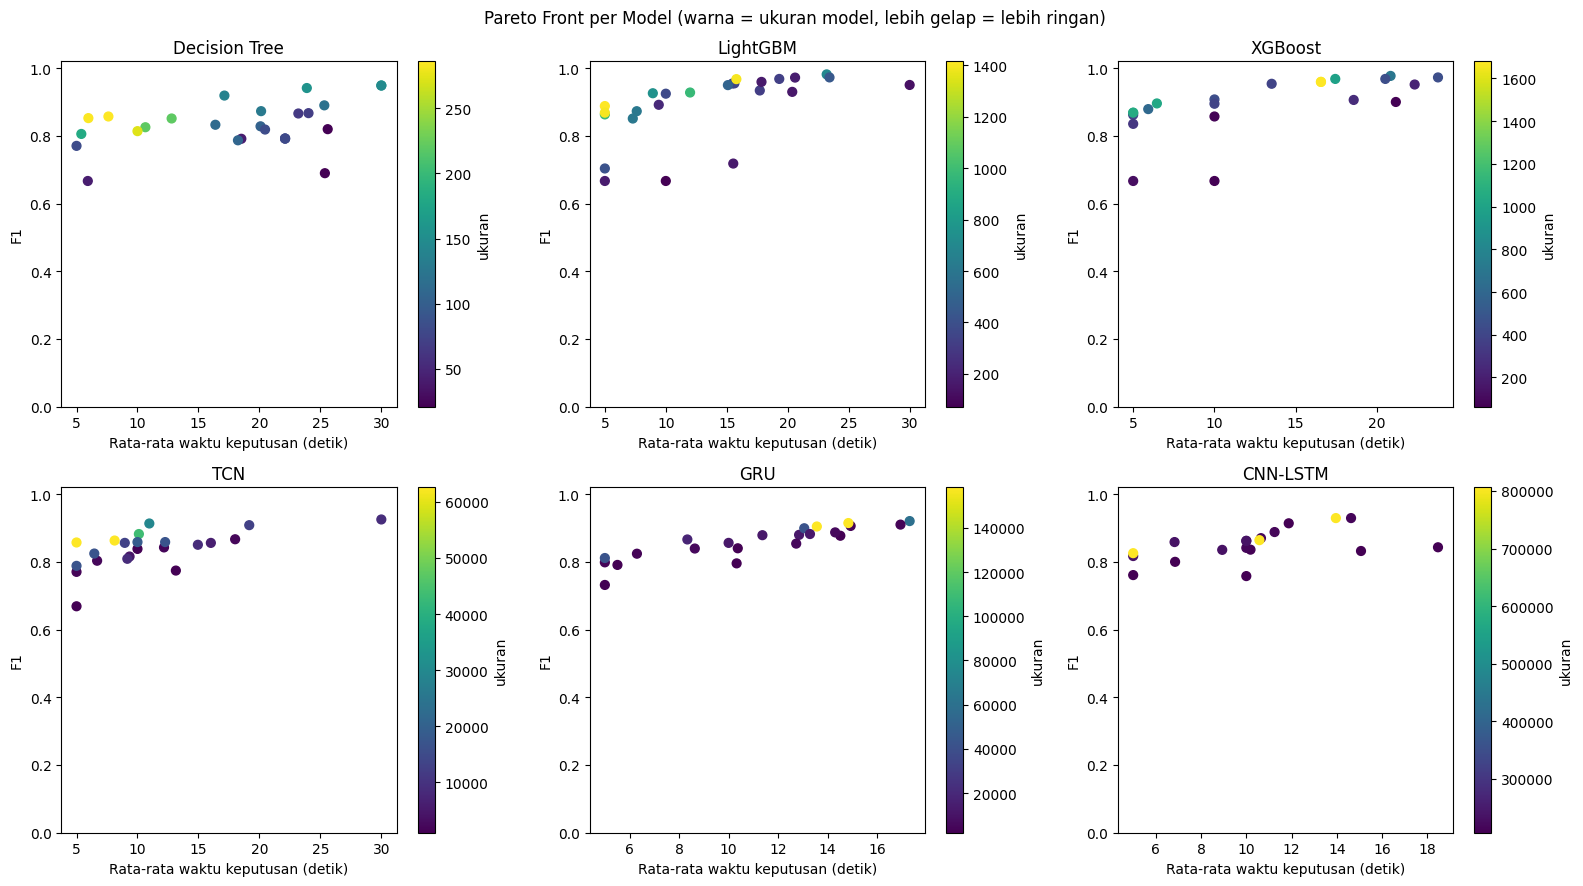

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, name in zip(axes, MODEL_NAMES):
    sub = pareto_df[pareto_df.model == name]
    sc = ax.scatter(sub["avg_time_s"], sub["f1"], c=sub["size"], cmap="viridis", s=40)
    ax.set_title(name)
    ax.set_xlabel("Rata-rata waktu keputusan (detik)")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.02)
    fig.colorbar(sc, ax=ax, label="ukuran")
fig.suptitle("Pareto Front per Model (warna = ukuran model, lebih gelap = lebih ringan)")
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
from collections import Counter

SEARCH_SPACE = {
    "Decision Tree": {
        "dtree_max_depth": {"type": "int", "low": 2, "high": 20},
        "dtree_min_samples_leaf": {"type": "int", "low": 1, "high": 20},
    },
    "LightGBM": {
        "lgbm_n_estimators": {"type": "int", "low": 20, "high": 300},
        "lgbm_max_depth": {"type": "int", "low": 2, "high": 12},
        "lgbm_learning_rate": {"type": "float_log", "low": 0.001, "high": 0.3},
        "lgbm_num_leaves": {"type": "int", "low": 7, "high": 127},
        "lgbm_subsample": {"type": "float", "low": 0.5, "high": 1.0},
    },
    "XGBoost": {
        "xgb_n_estimators": {"type": "int", "low": 20, "high": 300},
        "xgb_max_depth": {"type": "int", "low": 2, "high": 12},
        "xgb_learning_rate": {"type": "float_log", "low": 0.001, "high": 0.3},
        "xgb_subsample": {"type": "float", "low": 0.5, "high": 1.0},
    },
    "TCN": {
        "tcn_n_blocks": {"type": "int", "low": 1, "high": 4},
        "tcn_filters": {"type": "cat", "values": [8, 16, 32, 64]},
        "tcn_kernel_size": {"type": "cat", "values": [2, 3, 5]},
        "tcn_lr": {"type": "float_log", "low": 1e-4, "high": 1e-2},
        "tcn_dropout": {"type": "float", "low": 0.0, "high": 0.5},
    },
    "GRU": {
        "gru_units": {"type": "cat", "values": [16, 32, 64, 128]},
        "gru_n_layers": {"type": "int", "low": 1, "high": 2},
        "gru_lr": {"type": "float_log", "low": 1e-4, "high": 1e-2},
        "gru_dropout": {"type": "float", "low": 0.0, "high": 0.5},
    },
    "CNN-LSTM": {
        "cnnlstm_conv_filters": {"type": "cat", "values": [16, 32, 64]},
        "cnnlstm_kernel_size": {"type": "cat", "values": [2, 3, 5]},
        "cnnlstm_lstm_units": {"type": "cat", "values": [128, 256]},
        "cnnlstm_lr": {"type": "float_log", "low": 1e-4, "high": 1e-2},
        "cnnlstm_dropout": {"type": "float", "low": 0.0, "high": 0.5},
    },
}

ECONOMY_SPACE = {
    "economy_K": {"type": "int", "low": 2, "high": 8},
    "economy_alpha": {"type": "float_log", "low": 1e-3, "high": 10.0},
    "economy_beta": {"type": "float_log", "low": 1.0, "high": 50.0},
}


def analyze_param(trials, param_name, spec):
    values = [t.params[param_name] for t in trials if param_name in t.params]
    if not values:
        return None
    if spec["type"] == "cat":
        counts = Counter(values)
        top_val = spec["values"][-1]
        bottom_val = spec["values"][0]
        n = len(values)
        return {
            "param": param_name, "tipe": "kategorikal",
            "distribusi": dict(counts),
            "frac_di_batas_atas": counts.get(top_val, 0) / n,
            "frac_di_batas_bawah": counts.get(bottom_val, 0) / n,
        }
    arr = np.array(values, dtype=float)
    if spec["type"] == "float_log":
        low_t, high_t = np.log10(spec["low"]), np.log10(spec["high"])
        arr_t = np.log10(arr)
    else:
        low_t, high_t = spec["low"], spec["high"]
        arr_t = arr
    span = high_t - low_t
    return {
        "param": param_name, "tipe": "numerik",
        "min": arr.min(), "max": arr.max(), "mean": arr.mean(),
        "batas_pencarian": (spec["low"], spec["high"]),
        "frac_dekat_batas_atas": float((arr_t > high_t - 0.1 * span).mean()),
        "frac_dekat_batas_bawah": float((arr_t < low_t + 0.1 * span).mean()),
    }


def report_model(study, model_name, param_specs, top_n=20):
    trials = sorted(study.best_trials, key=lambda t: t.values[0], reverse=True)[:top_n]
    print(f"{'=' * 70}\n{model_name} -- dianalisis dari {len(trials)} trial Pareto-optimal F1 tertinggi\n{'=' * 70}")
    any_flag = False
    all_specs = {**param_specs, **ECONOMY_SPACE}
    for pname, spec in all_specs.items():
        res = analyze_param(trials, pname, spec)
        if res is None:
            continue
        if res["tipe"] == "kategorikal":
            flag = res["frac_di_batas_atas"] > 0.5
            tag = "  [PERHATIAN: mentok batas]" if flag else ""
            print(f"  {pname:22s}: distribusi kategori {res['distribusi']}{tag}")
        else:
            flag = res["frac_dekat_batas_atas"] > 0.5 or res["frac_dekat_batas_bawah"] > 0.5
            tag = "  [PERHATIAN: mentok batas]" if flag else ""
            print(f"  {pname:22s}: rentang cari {res['batas_pencarian']}, "
                  f"nilai terpilih [{res['min']:.4g}, {res['max']:.4g}], rata2={res['mean']:.4g}{tag}")
        any_flag = any_flag or flag
    return any_flag

## Pemilihan Solusi Akhir per Model (Entropy-Weight TOPSIS)

In [12]:
def entropy_weight_topsis(df, criteria, senses):
    """Entropy-Weight TOPSIS (Hwang & Yoon, 1981; bobot lewat entropi Shannon, 1948).
    criteria: kolom objektif. senses: '+' benefit, '-' cost."""
    X = df[criteria].to_numpy(dtype=float)
    m, n = X.shape

    R = np.zeros_like(X)
    for j in range(n):
        col = X[:, j]
        lo, hi = col.min(), col.max()
        if hi == lo:
            R[:, j] = 1.0
        elif senses[j] == "+":
            R[:, j] = (col - lo) / (hi - lo)
        else:
            R[:, j] = (hi - col) / (hi - lo)

    P = R / R.sum(axis=0, keepdims=True)
    P_safe = np.where(P == 0, 1.0, P)
    e = -1.0 / np.log(m) * (P * np.log(P_safe)).sum(axis=0)
    w = (1.0 - e) / (1.0 - e).sum()

    V = R * w
    ideal_best, ideal_worst = V.max(axis=0), V.min(axis=0)
    dist_best = np.sqrt(((V - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((V - ideal_worst) ** 2).sum(axis=1))

    out = df.copy()
    out["closeness"] = dist_worst / (dist_best + dist_worst)
    for j, c in enumerate(criteria):
        out[f"w_{c}"] = w[j]
    return out.sort_values("closeness", ascending=False)


CRITERIA = ["f1", "avg_time_s", "size"]
SENSES = ["+", "-", "-"]

stage1_rows = []
ranked_by_model = {}
for name in MODEL_NAMES:
    sub = pareto_df[pareto_df.model == name].reset_index(drop=True)
    ranked = entropy_weight_topsis(sub, CRITERIA, SENSES)
    ranked_by_model[name] = ranked
    w = ranked.iloc[0]
    print(f"\n{'=' * 70}\n{name} -- {len(sub)} kandidat Pareto-optimal, bobot entropi "
          f"f1={w.w_f1:.3f} avg_time_s={w.w_avg_time_s:.3f} size={w.w_size:.3f}\n{'=' * 70}")
    print(ranked[["trial", "step", "f1", "avg_time_s", "size", "closeness"]].to_string(index=False))
    print(f"-- terpilih: trial {int(w.trial)} (closeness={w.closeness:.4f})")
    stage1_rows.append(w)

stage1_df = pd.DataFrame(stage1_rows).reset_index(drop=True)
stage1_df.to_csv("/kaggle/working/nb4_topsis_stage1.csv", index=False)
print("\nDisimpan: nb4_topsis_stage1.csv")
print(stage1_df[["model", "trial", "step", "f1", "avg_time_s", "size", "closeness"]].to_string(index=False))


Decision Tree -- 26 kandidat Pareto-optimal, bobot entropi f1=0.214 avg_time_s=0.457 size=0.329
 trial  step       f1  avg_time_s  size  closeness
    69     5 0.770370    5.000000  82.0   0.773061
    10     5 0.666667    5.925926  42.0   0.711902
    78     5 0.805556    5.393519 182.0   0.678041
     6    10 0.832685   16.388889 113.0   0.581577
    29     5 0.791304   18.518519  42.0   0.579943
    71     5 0.852321    5.972222 284.0   0.579007
    26     5 0.825397   10.648148 220.0   0.574065
    28    10 0.918919   17.129630 137.0   0.572386
    22     5 0.857143    7.615741 286.0   0.560737
    21     5 0.851240   12.800926 220.0   0.545402
    80    10 0.813853   10.000000 273.0   0.528097
    66    10 0.786765   18.240741 107.0   0.525002
    86     5 0.818565   20.462963  82.0   0.515406
    82    10 0.828125   20.092593 103.0   0.505948
    85    10 0.872881   20.138889 129.0   0.496247
    11    10 0.865979   23.194444  65.0   0.495878
    18    10 0.819672   25.601852  2

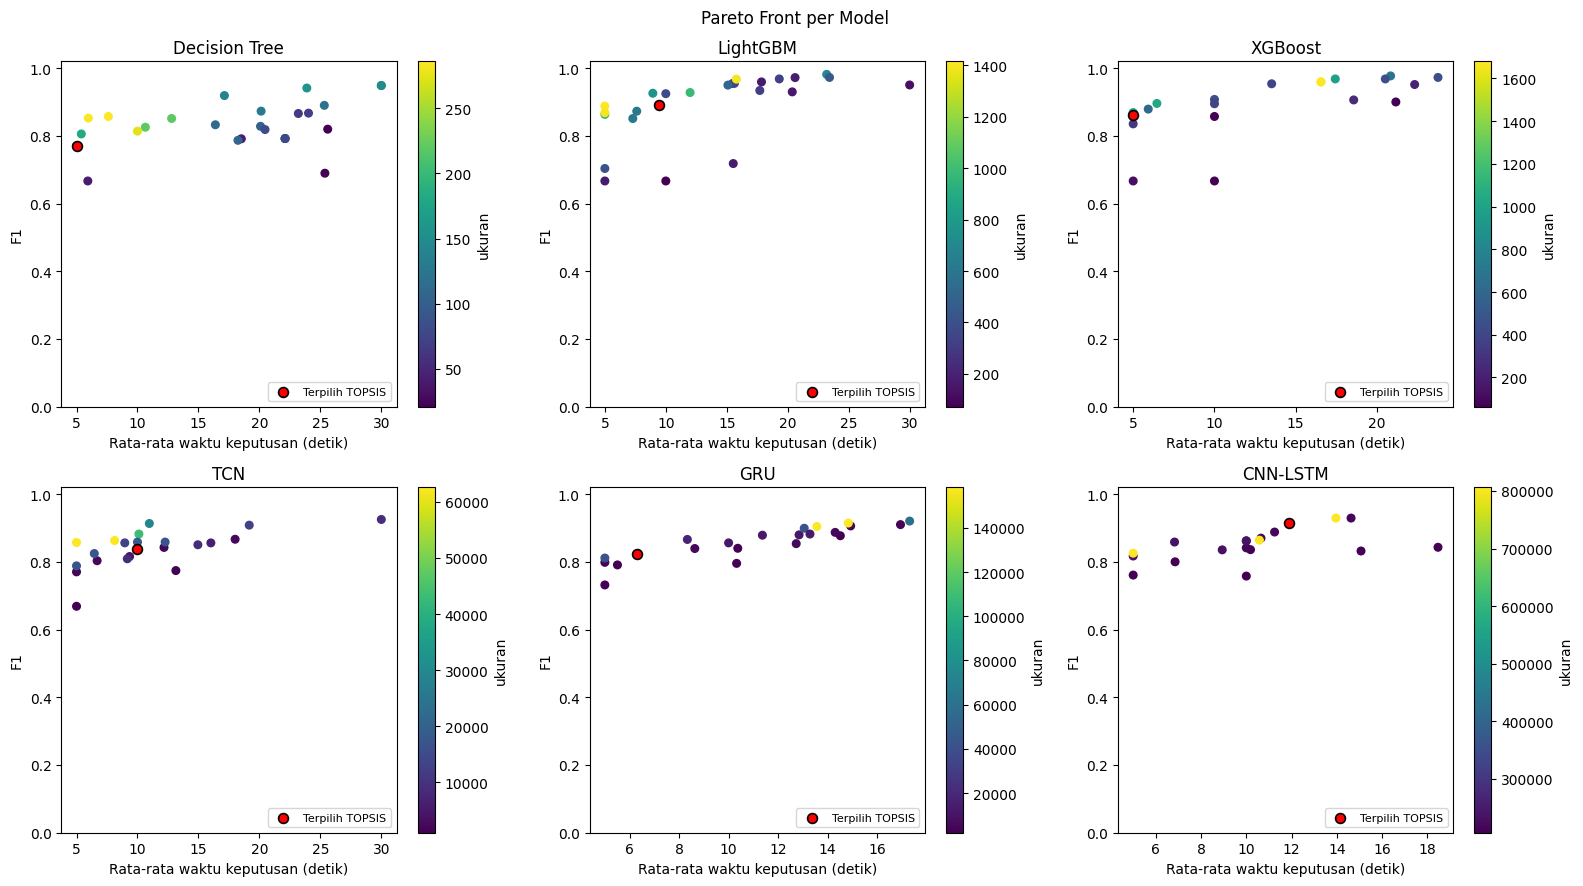

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, name in zip(axes, MODEL_NAMES):
    sub = pareto_df[pareto_df.model == name]
    sc = ax.scatter(sub["avg_time_s"], sub["f1"], c=sub["size"], cmap="viridis", s=30)
    winner = stage1_df[stage1_df.model == name].iloc[0]
    ax.scatter(winner["avg_time_s"], winner["f1"], marker="o", s=50, c="red",
               edgecolors="black", linewidths=1.2, zorder=5, label="Terpilih TOPSIS")
    ax.set_title(name)
    ax.set_xlabel("Rata-rata waktu keputusan (detik)")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right", fontsize=8)
    fig.colorbar(sc, ax=ax, label="ukuran")
fig.suptitle("Pareto Front per Model")
plt.tight_layout()
plt.savefig("/kaggle/working/nb4_pareto_topsis.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
def entropy_weight_topsis(df, criteria, senses):
    """Entropy-Weight TOPSIS (Hwang & Yoon, 1981; bobot lewat entropi Shannon, 1948).
    criteria: kolom objektif. senses: '+' benefit, '-' cost."""
    X = df[criteria].to_numpy(dtype=float)
    m, n = X.shape

    R = np.zeros_like(X)
    for j in range(n):
        col = X[:, j]
        lo, hi = col.min(), col.max()
        if hi == lo:
            R[:, j] = 1.0
        elif senses[j] == "+":
            R[:, j] = (col - lo) / (hi - lo)
        else:
            R[:, j] = (hi - col) / (hi - lo)

    P = R / R.sum(axis=0, keepdims=True)
    P_safe = np.where(P == 0, 1.0, P)
    e = -1.0 / np.log(m) * (P * np.log(P_safe)).sum(axis=0)
    w = (1.0 - e) / (1.0 - e).sum()

    V = R * w
    ideal_best, ideal_worst = V.max(axis=0), V.min(axis=0)
    dist_best = np.sqrt(((V - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((V - ideal_worst) ** 2).sum(axis=1))

    out = df.copy()
    out["closeness"] = dist_worst / (dist_best + dist_worst)
    for j, c in enumerate(criteria):
        out[f"w_{c}"] = w[j]
    return out.sort_values("closeness", ascending=False)


CRITERIA = ["f1", "avg_time_s", "size"]
SENSES = ["+", "-", "-"]
F1_FLOOR_FRAC = 0.90
NEAR_MISS_MARGIN = 0.03

stage1_rows = []
for name in MODEL_NAMES:
    sub = pareto_df[pareto_df.model == name].reset_index(drop=True)
    f1_max = sub["f1"].max()
    f1_floor = F1_FLOOR_FRAC * f1_max
    survivors = sub[sub.f1 >= f1_floor].reset_index(drop=True)
    excluded = sub[sub.f1 < f1_floor].reset_index(drop=True)

    ranked = entropy_weight_topsis(survivors, CRITERIA, SENSES)
    w = ranked.iloc[0]

    print(f"\n{'=' * 70}\n{name} -- {len(sub)} kandidat Pareto-optimal\n{'=' * 70}")
    print(f"F1 maks={f1_max:.4f}, ambang {F1_FLOOR_FRAC:.0%}={f1_floor:.4f}, "
          f"lolos filter={len(survivors)}/{len(sub)}")
    print(f"bobot entropi (di antara yang lolos): f1={w.w_f1:.3f}  "
          f"avg_time_s={w.w_avg_time_s:.3f}  size={w.w_size:.3f}")
    print(ranked[["trial", "step", "f1", "avg_time_s", "size", "closeness"]].to_string(index=False))
    print(f"-- terpilih: trial {int(w.trial)} (closeness={w.closeness:.4f})")

    dominators = excluded[
        (excluded.avg_time_s < w.avg_time_s)
        & (excluded["size"] < w["size"])
        & (excluded.f1 >= w.f1 - NEAR_MISS_MARGIN)
    ]
    if len(dominators):
        print(f"[FLAG] {len(dominators)} kandidat tersingkir ambang menang telak di "
              f"avg_time_s & size dengan F1 <= {NEAR_MISS_MARGIN} di bawah pemenang:")
        print(dominators[["trial", "f1", "avg_time_s", "size"]].to_string(index=False))
    else:
        print(f"[OK] tidak ada kandidat tersingkir yang mendominasi time & size "
              f"dengan selisih F1 <= {NEAR_MISS_MARGIN}")

    stage1_rows.append(w)

stage1_df = pd.DataFrame(stage1_rows).reset_index(drop=True)
stage1_df.to_csv("/kaggle/working/nb4_topsis_stage1.csv", index=False)
print("\nDisimpan: nb4_topsis_stage1.csv")
print(stage1_df[["model", "trial", "step", "f1", "avg_time_s", "size", "closeness"]].to_string(index=False))


Decision Tree -- 26 kandidat Pareto-optimal
F1 maks=0.9488, ambang 90%=0.8540, lolos filter=9/26
bobot entropi (di antara yang lolos): f1=0.419  avg_time_s=0.429  size=0.152
 trial  step       f1  avg_time_s  size  closeness
    28    10 0.918919   17.129630 137.0   0.624904
    12    10 0.941176   23.888889 157.0   0.562011
    64    10 0.948357   30.000000 147.0   0.496809
     0    10 0.948837   30.000000 167.0   0.495254
    22     5 0.857143    7.615741 286.0   0.490738
    85    10 0.872881   20.138889 129.0   0.350750
    25    10 0.890000   25.324074 121.0   0.323895
    11    10 0.865979   23.194444  65.0   0.297381
    74    10 0.866995   24.027778  69.0   0.283272
-- terpilih: trial 28 (closeness=0.6249)
[OK] tidak ada kandidat tersingkir yang mendominasi time & size dengan selisih F1 <= 0.03

LightGBM -- 25 kandidat Pareto-optimal
F1 maks=0.9815, ambang 90%=0.8833, lolos filter=17/25
bobot entropi (di antara yang lolos): f1=0.358  avg_time_s=0.294  size=0.348
 trial  step 

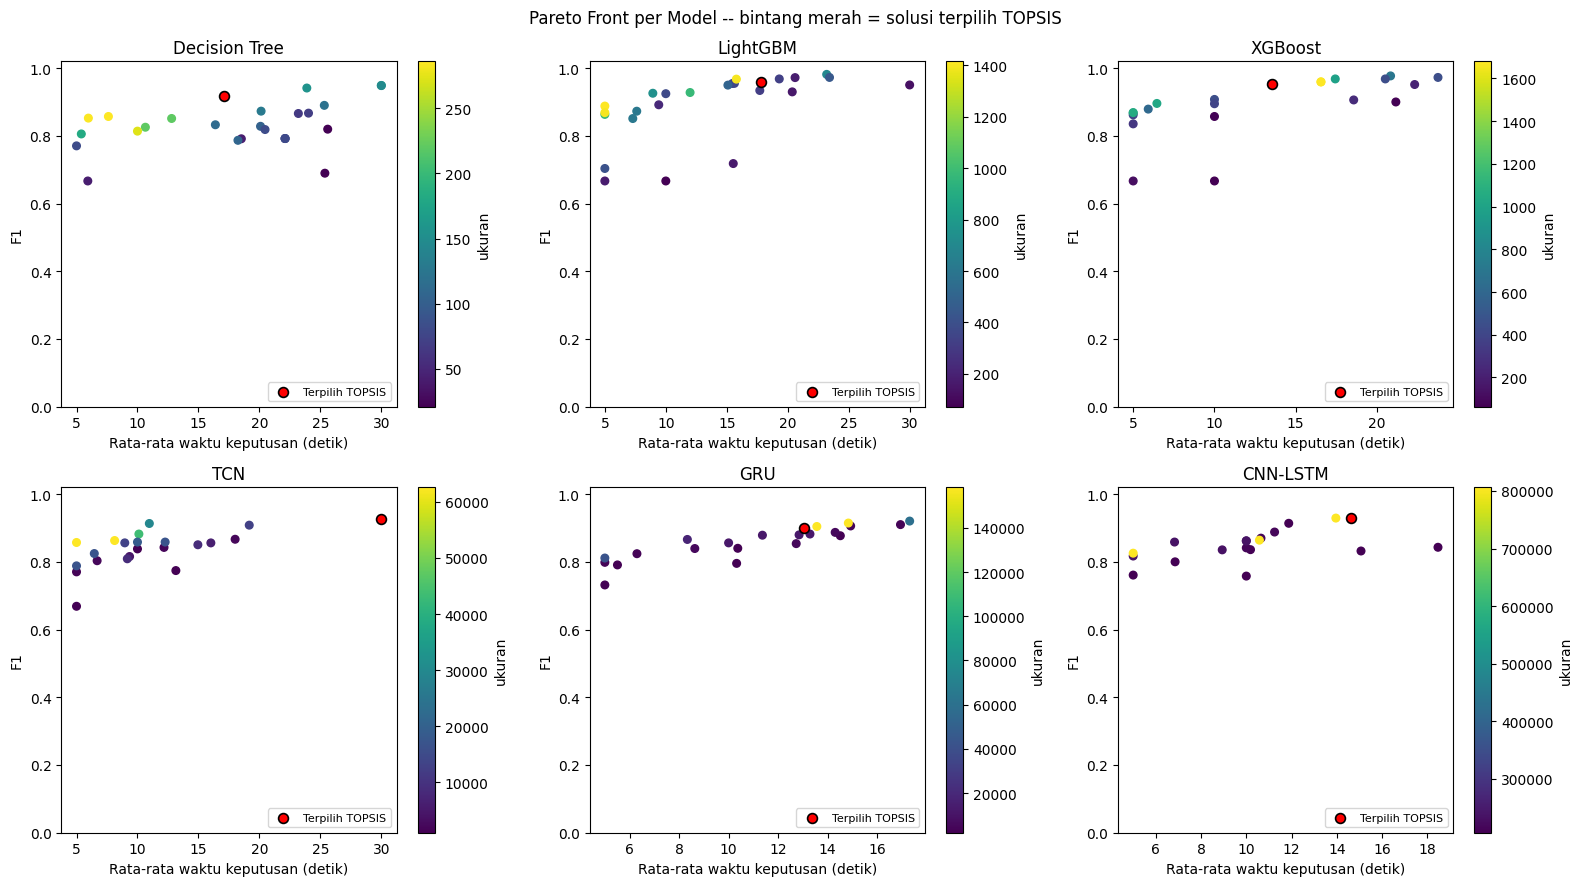

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, name in zip(axes, MODEL_NAMES):
    sub = pareto_df[pareto_df.model == name]
    sc = ax.scatter(sub["avg_time_s"], sub["f1"], c=sub["size"], cmap="viridis", s=30)
    winner = stage1_df[stage1_df.model == name].iloc[0]
    ax.scatter(winner["avg_time_s"], winner["f1"], marker="o", s=50, c="red",
               edgecolors="black", linewidths=1.2, zorder=5, label="Terpilih TOPSIS")
    ax.set_title(name)
    ax.set_xlabel("Rata-rata waktu keputusan (detik)")
    ax.set_ylabel("F1")
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right", fontsize=8)
    fig.colorbar(sc, ax=ax, label="ukuran")
fig.suptitle("Pareto Front per Model -- bintang merah = solusi terpilih TOPSIS")
plt.tight_layout()
plt.savefig("/kaggle/working/nb4_pareto_topsis.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
!zip -r hasil_output.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/__notebook__.ipynb (deflated 51%)
  adding: kaggle/working/optuna_decision_tree.db (deflated 89%)
  adding: kaggle/working/optuna_cnnlstm.db (deflated 88%)
  adding: kaggle/working/optuna_gru.db (deflated 88%)
  adding: kaggle/working/optuna_lightgbm.db (deflated 88%)
  adding: kaggle/working/nb4_pareto_fronts.csv (deflated 69%)
  adding: kaggle/working/nb4_pareto_topsis.png (deflated 15%)
  adding: kaggle/working/optuna_tcn.db (deflated 88%)
  adding: kaggle/working/optuna_xgboost.db (deflated 88%)
  adding: kaggle/working/nb4_topsis_stage1.csv (deflated 44%)
